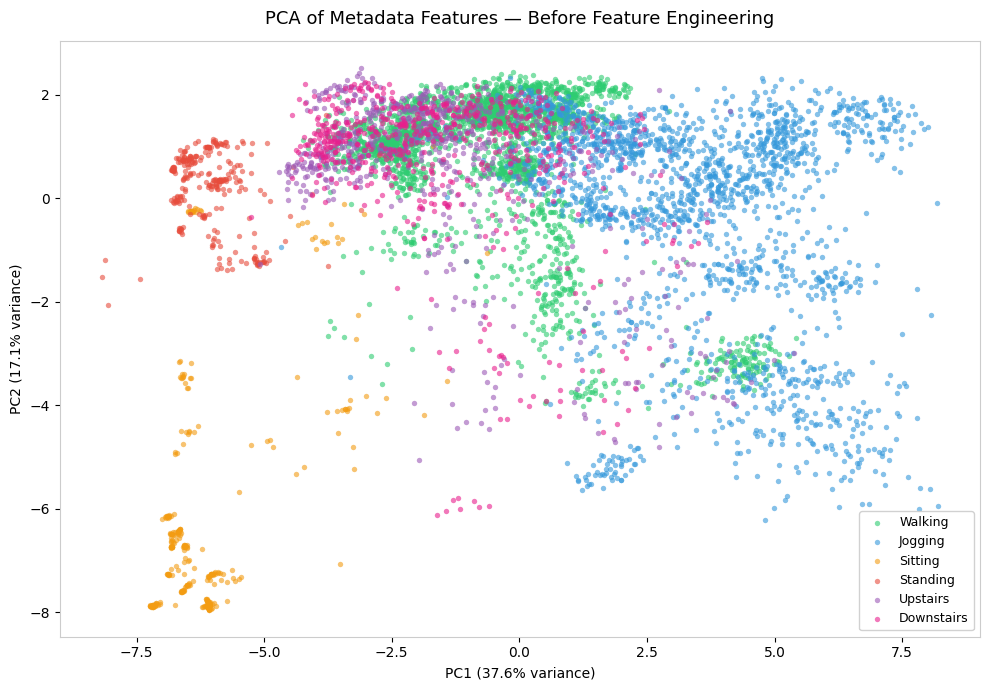

Saved: pca_metadata.png | PC1=37.6% PC2=17.1%
Extracting features (3 windows per snippet)...
Train done.
Test done.
Kaggle done.
Total features: 279 | NaN count: 8


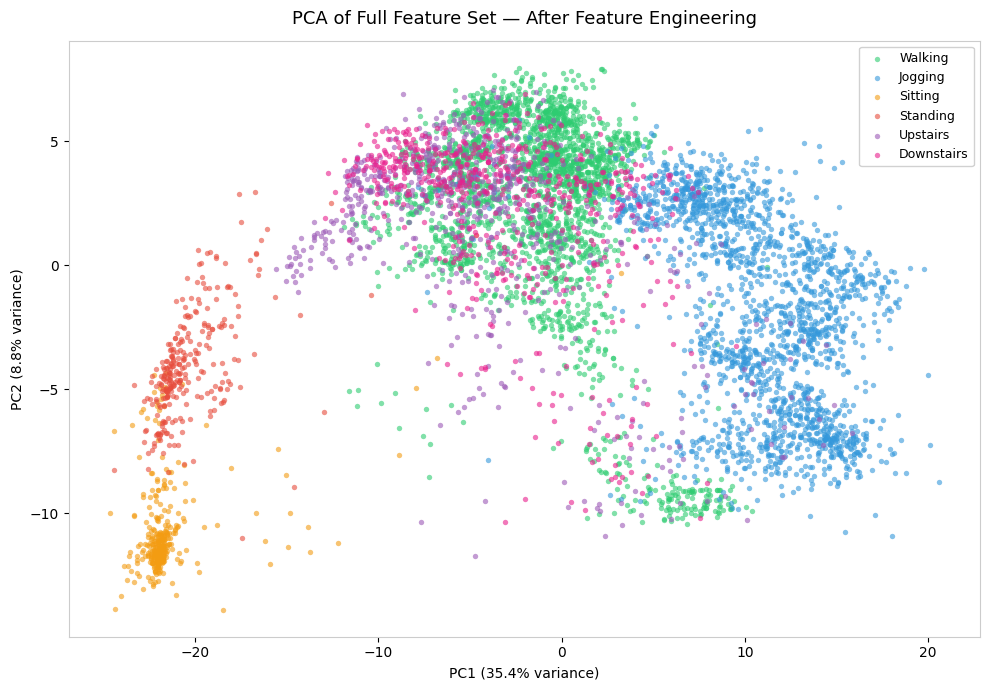

Saved: pca_engineered_features.png | PC1=35.4% PC2=8.8%
CV fold scores : [np.float64(0.8451), np.float64(0.8728), np.float64(0.851), np.float64(0.7099), np.float64(0.8751)]
Mean CV        : 83.08% | Std: 6.16%
Train accuracy : 100.00%
Test accuracy  : 90.02%
              precision    recall  f1-score   support

  Downstairs       0.73      0.73      0.73       174
     Jogging       0.96      0.98      0.97       689
     Sitting       0.81      1.00      0.90        22
    Standing       1.00      0.88      0.94        43
    Upstairs       0.81      0.61      0.70       238
     Walking       0.91      0.96      0.93       768

    accuracy                           0.90      1934
   macro avg       0.87      0.86      0.86      1934
weighted avg       0.90      0.90      0.90      1934



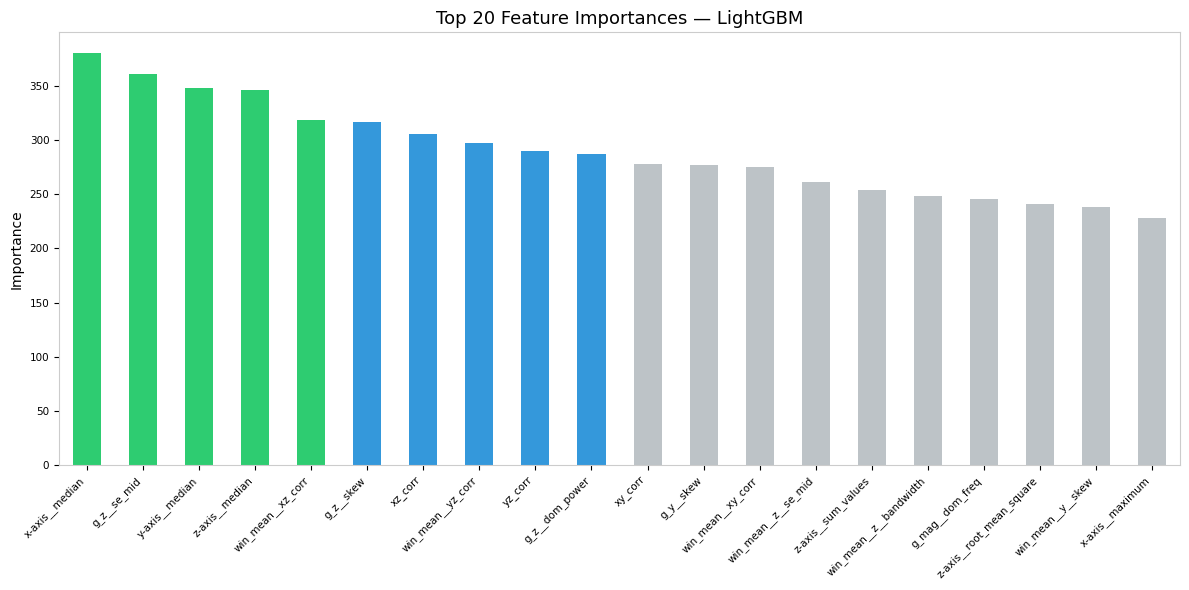

Predictions saved: predictions_LightGBM_windowed.csv
prediction
Walking       892
Jogging       636
Upstairs      332
Sitting       267
Downstairs    224
Standing      155
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.fft import fft
from scipy.signal import find_peaks
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
train      = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/metadata.csv')
test       = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/metadata_test.csv')
kaggle     = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/metadata_kaggle.csv')
sig_train  = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/signals.csv')
sig_test   = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/signals_test.csv')
sig_kaggle = pd.read_csv('/kaggle/input/datasets/amiolaonabanjo/metadata/signals_kaggle.csv')

META_COLS = [c for c in train.columns if c not in ['user_snippet', 'activity']]

# ─────────────────────────────────────────
# 2. PCA VISUALISATION
#    Applied to the 30 metadata features
#    to assess class separability before
#    feature engineering. Identifies which
#    activity classes are structurally
#    difficult to separate.
# ─────────────────────────────────────────
COLORS = {
    'Walking':    '#2ecc71',
    'Jogging':    '#3498db',
    'Sitting':    '#f39c12',
    'Standing':   '#e74c3c',
    'Upstairs':   '#9b59b6',
    'Downstairs': '#e91e8c'
}

def plot_pca(X, y, title, filename):
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    pca    = PCA(n_components=2)
    X_pca  = pca.fit_transform(X_sc)
    var    = pca.explained_variance_ratio_
    fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
    ax.set_facecolor('white')
    for activity, color in COLORS.items():
        mask = y == activity
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, label=activity, alpha=0.6, s=15, linewidths=0)
    ax.set_title(title, color='black', fontsize=13, pad=12)
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', color='black', fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', color='black', fontsize=10)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.legend(framealpha=0.9, facecolor='white', edgecolor='#cccccc',
              labelcolor='black', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, facecolor='white')
    plt.show()
    print(f"Saved: {filename} | PC1={var[0]*100:.1f}% PC2={var[1]*100:.1f}%")

# PCA on metadata features — before feature engineering
plot_pca(
    train[META_COLS], train['activity'],
    'PCA of Metadata Features — Before Feature Engineering',
    'pca_metadata.png'
)

# ─────────────────────────────────────────
# 3. FEATURE EXTRACTION
#    Features extracted per axis and per
#    signal magnitude across four groups:
#    (a) Time domain statistics
#    (b) Jerk — first derivative of signal
#    (c) Frequency domain via FFT
#    (d) Cross-axis correlations
# ─────────────────────────────────────────
def features_from_array(axis, label):
    n = len(axis)
    if n < 2:
        return {f'{label}__{k}': 0.0 for k in [
            'zcr', 'peak_count', 'energy', 'iqr', 'skew', 'kurt', 'mad', 'rms', 'range',
            'jerk_mean', 'jerk_std', 'jerk_energy',
            'dom_freq', 'dom_power', 'se_low', 'se_mid', 'se_high',
            'centroid', 'bandwidth', 'spectral_entropy'
        ]}

    row = {}

    # (a) Time domain
    row[f'{label}__zcr']        = np.sum(np.diff(np.sign(axis)) != 0) / n
    peaks, _                    = find_peaks(axis)
    row[f'{label}__peak_count'] = len(peaks) / n
    row[f'{label}__energy']     = np.sum(axis**2) / n
    row[f'{label}__iqr']        = np.percentile(axis, 75) - np.percentile(axis, 25)
    row[f'{label}__skew']       = stats.skew(axis)
    row[f'{label}__kurt']       = stats.kurtosis(axis)
    row[f'{label}__mad']        = np.mean(np.abs(axis - np.mean(axis)))
    row[f'{label}__rms']        = np.sqrt(np.mean(axis**2))
    row[f'{label}__range']      = np.max(axis) - np.min(axis)

    # (b) Jerk — rate of change of acceleration
    # Stair activities produce sharp directional changes
    # that level walking does not, making jerk a key
    # discriminator between these activity classes
    jerk = np.diff(axis)
    if len(jerk) > 0:
        row[f'{label}__jerk_mean']   = np.mean(np.abs(jerk))
        row[f'{label}__jerk_std']    = np.std(jerk)
        row[f'{label}__jerk_energy'] = np.sum(jerk**2) / len(jerk)
    else:
        row[f'{label}__jerk_mean']   = 0.0
        row[f'{label}__jerk_std']    = 0.0
        row[f'{label}__jerk_energy'] = 0.0

    # (c) Frequency domain via FFT
    # Walking energy concentrates at 1-2Hz, jogging at 2-3Hz.
    # Stair activities fall in similar bands but differ in
    # how energy distributes across axes and magnitude.
    fft_vals = np.abs(fft(axis))[:n//2]
    freqs    = np.fft.fftfreq(n, d=0.05)[:n//2]

    if len(fft_vals) > 1:
        dom_idx = np.argmax(fft_vals[1:]) + 1
        row[f'{label}__dom_freq']  = freqs[dom_idx]
        row[f'{label}__dom_power'] = fft_vals[dom_idx]
    else:
        row[f'{label}__dom_freq']  = 0.0
        row[f'{label}__dom_power'] = 0.0

    total_e = np.sum(fft_vals**2) + 1e-10
    row[f'{label}__se_low']  = np.sum(fft_vals[(freqs >= 0) & (freqs < 1)]**2)  / total_e
    row[f'{label}__se_mid']  = np.sum(fft_vals[(freqs >= 1) & (freqs < 3)]**2)  / total_e
    row[f'{label}__se_high'] = np.sum(fft_vals[(freqs >= 3) & (freqs < 10)]**2) / total_e

    if np.sum(fft_vals) > 0:
        c = np.sum(freqs * fft_vals) / np.sum(fft_vals)
        row[f'{label}__centroid']  = c
        row[f'{label}__bandwidth'] = np.sqrt(
            np.sum(((freqs - c)**2) * fft_vals) / np.sum(fft_vals))
    else:
        row[f'{label}__centroid']  = 0.0
        row[f'{label}__bandwidth'] = 0.0

    psd = fft_vals**2 / total_e
    psd = psd[psd > 0]
    row[f'{label}__spectral_entropy'] = -np.sum(psd * np.log2(psd))

    return row

# ─────────────────────────────────────────
# 4. WINDOWED FEATURE EXTRACTION
#    Each 10-second snippet is split into
#    3 sub-windows of ~33 samples each.
#    Features are extracted per window then
#    summarised with mean and std across
#    windows. The std captures how much the
#    signal changes within the snippet —
#    a key discriminator for non-stationary
#    activities such as stair climbing.
# ─────────────────────────────────────────
N_WINDOWS = 3

def extract_windowed_features(signals_df):
    features = []

    for snippet_id, group in signals_df.groupby('user_snippet'):
        x   = group['x-axis'].values
        y   = group['y-axis'].values
        z   = group['z-axis'].values
        n   = len(x)
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {'user_snippet': snippet_id}

        # Global features over full snippet
        for axis_name, axis in [('x', x), ('y', y), ('z', z), ('mag', mag)]:
            row.update(features_from_array(axis, f'g_{axis_name}'))

        # (d) Cross-axis correlations over full snippet
        # Upstairs and downstairs differ in how x, y, z co-vary
        # due to the body tilting differently during ascent vs descent
        row['xy_corr'] = np.corrcoef(x, y)[0, 1] if n > 1 else 0.0
        row['xz_corr'] = np.corrcoef(x, z)[0, 1] if n > 1 else 0.0
        row['yz_corr'] = np.corrcoef(y, z)[0, 1] if n > 1 else 0.0

        # Sub-window extraction
        window_size = max(n // N_WINDOWS, 2)
        window_feats_list = []

        for w in range(N_WINDOWS):
            start = w * window_size
            end   = start + window_size if w < N_WINDOWS - 1 else n
            xw = x[start:end]; yw = y[start:end]; zw = z[start:end]
            magw = np.sqrt(xw**2 + yw**2 + zw**2)

            w_row = {}
            for axis_name, axis in [('x', xw), ('y', yw), ('z', zw), ('mag', magw)]:
                w_row.update(features_from_array(axis, axis_name))

            w_row['xy_corr'] = np.corrcoef(xw, yw)[0, 1] if len(xw) > 1 else 0.0
            w_row['xz_corr'] = np.corrcoef(xw, zw)[0, 1] if len(xw) > 1 else 0.0
            w_row['yz_corr'] = np.corrcoef(yw, zw)[0, 1] if len(yw) > 1 else 0.0

            window_feats_list.append(w_row)

        # Aggregate across windows
        for key in window_feats_list[0].keys():
            vals = [wf[key] for wf in window_feats_list]
            row[f'win_mean__{key}'] = np.mean(vals)
            row[f'win_std__{key}']  = np.std(vals)

        features.append(row)

    return pd.DataFrame(features).set_index('user_snippet')

# ─────────────────────────────────────────
# 5. EXTRACT FEATURES FROM ALL SPLITS
# ─────────────────────────────────────────
print(f"Extracting features ({N_WINDOWS} windows per snippet)...")
sf_train  = extract_windowed_features(sig_train);  print("Train done.")
sf_test   = extract_windowed_features(sig_test);   print("Test done.")
sf_kaggle = extract_windowed_features(sig_kaggle); print("Kaggle done.")

# ─────────────────────────────────────────
# 6. MERGE FEATURES WITH METADATA
# ─────────────────────────────────────────
def merge(meta_df, sf):
    return meta_df.set_index('user_snippet').join(sf, how='left')

train_full  = merge(train,  sf_train)
test_full   = merge(test,   sf_test)
kaggle_full = merge(kaggle, sf_kaggle)

FEATURE_COLS = [c for c in train_full.columns if c != 'activity']
X_train  = train_full[FEATURE_COLS]
y_train  = train_full['activity']
X_test   = test_full[FEATURE_COLS]
y_test   = test_full['activity']
X_kaggle = kaggle_full[FEATURE_COLS]

# User IDs for GroupKFold cross-validation
groups = train['user_snippet'].apply(lambda x: x.split('_')[0])

print(f"Total features: {X_train.shape[1]} | NaN count: {X_train.isna().sum().sum()}")

## ─────────────────────────────────────────
# 7. PCA ON FULL FEATURE SET
#    Compared against metadata-only PCA
#    to show improvement in class
#    separability after feature engineering
# ─────────────────────────────────────────
# Fill NaNs with median for PCA only — LightGBM handles NaNs natively
X_train_pca = X_train.fillna(X_train.median())
plot_pca(
    X_train_pca, y_train,
    'PCA of Full Feature Set — After Feature Engineering',
    'pca_engineered_features.png'
)

# ─────────────────────────────────────────
# 8. MODEL — LIGHTGBM
#    Histogram-based gradient boosting.
#    Feature and row subsampling reduce
#    variance across folds. L1 and L2
#    regularisation limit model complexity.
#    class_weight compensates for the
#    sitting and standing class imbalance.
# ─────────────────────────────────────────
gbm = LGBMClassifier(
    n_estimators      = 500,
    max_depth         = 4,
    num_leaves        = 31,
    learning_rate     = 0.06,
    min_child_samples = 40,
    reg_lambda        = 3.0,
    reg_alpha         = 0.1,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 1,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

# ─────────────────────────────────────────
# 9. USER-BASED CROSS-VALIDATION
#    GroupKFold ensures all snippets from
#    the same user stay within one fold.
#    This prevents data leakage — without
#    this, user-specific movement patterns
#    would inflate validation accuracy.
# ─────────────────────────────────────────
gkf = GroupKFold(n_splits=5)
cv_scores = cross_val_score(
    gbm, X_train, y_train,
    cv=gkf, groups=groups,
    scoring='accuracy', n_jobs=-1
)
print(f"CV fold scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV        : {cv_scores.mean()*100:.2f}% | Std: {cv_scores.std()*100:.2f}%")

# ─────────────────────────────────────────
# 10. TRAIN AND EVALUATE
# ─────────────────────────────────────────
gbm.fit(X_train, y_train)

train_acc = accuracy_score(y_train, gbm.predict(X_train))
test_acc  = accuracy_score(y_test,  gbm.predict(X_test))

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test accuracy  : {test_acc*100:.2f}%")
print(classification_report(y_test, gbm.predict(X_test)))

# ─────────────────────────────────────────
# 11. FEATURE IMPORTANCE PLOT
# ─────────────────────────────────────────
importances = pd.Series(gbm.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')
colors = ['#2ecc71' if i < 5 else '#3498db' if i < 10 else '#bdc3c7' for i in range(20)]
importances.head(20).plot(kind='bar', ax=ax, color=colors)
ax.set_title('Top 20 Feature Importances — LightGBM', color='black', fontsize=13)
ax.set_ylabel('Importance', color='black')
ax.tick_params(colors='black', labelsize=7.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, facecolor='white')
plt.show()

# ─────────────────────────────────────────
# 12. GENERATE PREDICTION FILE
# ─────────────────────────────────────────
submission = pd.DataFrame({
    'user_snippet': kaggle['user_snippet'],
    'prediction'  : gbm.predict(X_kaggle)
})
submission.to_csv('predictions_LightGBM_windowed.csv', index=False)
print(f"Predictions saved: predictions_LightGBM_windowed.csv")
print(submission['prediction'].value_counts())